# Pairwise E-distance — Figure 3A & Data S5

**Summary.** This notebook computes pairwise **E-distance** (energy distance in PCA space) between perturbation conditions for the whole brain invivo perturbation screen, stratified by cell type (neighborhood and whole brain), and produces clustermap visualizations for Figure 3A and Figure S8.

- **Inputs:** Wilcoxon DE results (parquet) and QC-filtered AnnData (zarr). Only perturbation–cell type pairs with ≥5 DE genes (FDR &lt; 0.05, |LFC| &gt; 0.5) are kept.
- **Data subset:** Control (Non_target) and perturbed cells restricted to those significant conditions; concatenated for analysis. A synthetic `whole_brain` stratum is added.
- **E-distance:** For each stratum (each **neighborhood** and **whole_brain**), data are normalized, scaled, PCA’d; pertpy’s `Distance("edistance")` is used to compute pairwise E-distances between conditions (by `gene_target`). Double-neighborhood labels are skipped; gene targets with &lt;20 cells are dropped per stratum.
- **Outputs:** CSV matrices of pairwise E-distances per cell type under `analysis/e-distance/`, and clustermaps of log1p(E-distance) -- Data S5.

# Pairwise E-distance

In [1]:
%load_ext autoreload
%autoreload 2

import os
from tqdm import tqdm
import scanpy as sc

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
pd.set_option('display.max_columns', None)

import sys
sys.path.append("/workspace/wholebrainperturbseq")

In [2]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'

In [ ]:
BASE_DIR = "/data/wholebrain_crispr_atlas"

DE_GENES_DIR = f"{BASE_DIR}/analysis/de_analysis"

OUT_DIR = f"{BASE_DIR}/analysis/e-distance"
os.makedirs(OUT_DIR, exist_ok=True)

DATA_FILENAME = "WB8588_screen_gex_filtered.zarr"
DATA_PATH = os.path.join(BASE_DIR, DATA_FILENAME)

SUPP_DIR = f"{BASE_DIR}/supplementary_data"

LFC_THRESHOLD = 0.5
MIN_DE_GENES = 5

Identifying pertrubation-cell type pairs that are significant based on DE analysis:

In [11]:
df = pd.read_excel(f"{SUPP_DIR}/Data S4. Whole brain in vivo perturb-seq differentially expressed genes by Wilcoxon Rank Sum test.xlsx", header=1)
df_sig = df[(df["pvals_adj"] < 0.05) & (df["logfoldchanges"].abs() > LFC_THRESHOLD)]

In [14]:
from analysis_lib.plot_utils import summarize_de_genes_per_condition
de_summary, _, _, _ = summarize_de_genes_per_condition(
    df_sig, 
    min_de_genes=MIN_DE_GENES, 
    lfc_threshold=LFC_THRESHOLD, 
    plot=False,
    verbose=True,
    target_gene_col="gene_target",
    deg_col="deg_names",
)

de_genes = de_summary[de_summary["n_de_genes"] >= 5]["gene_target"].unique()
de_conditions = de_summary[de_summary["n_de_genes"] >= 5]["condition"].unique()
de_cell_types = de_summary[de_summary["n_de_genes"] >= 5]["group_name"].unique()

Number of conditions with at least  5  DE genes:  631
Number of unique target genes:  171
Number of unique group names:  22


Loading the data and subseting it to significant perturbation-cell type pairs only:

In [6]:
import anndata as ad
adata = ad.read_zarr(DATA_PATH)

# Adding a whole brain "cell type"
adata.obs["whole_brain"] = "whole_brain"

In [7]:
# Subseting control cells to only cell types that have significant DE
adata_control = adata[adata.obs["gene_target"] == "Non_target"].copy()
adata_control = adata_control[adata_control.obs["group_name"].isin(de_cell_types)]
adata_control

View of AnnData object with n_obs × n_vars = 204891 × 18152
    obs: 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'sample_label', 'sample_id', 'species', 'mouse', 'tissue', 'sex', 'diet', 'genotype', 'condition', 'project', 'experiment', 'batch', 'pooled_sample_id', 'channel', 'scp_name', 'num_guides', 'target_guide', 'gene_target', 'num_rna_umi', 'num_genes', 'pct_mt', 'passes_qc', 'guide_umi_top', 'guide_umi_second', 'guide_umis', 'log_ambient_mse', 'log_ambient_mse_norm', 'class_name', 'predicted_class_probability', 'subclass_name', 'predicted_subclass_probability', 'supertype_name', 'predicted_supertype_probability', 'cluster_name', 'predicted_cluster_probability', 'cell_type', 'neuron_type', 'neighborhood', 'region_level1', 'region_level2', 'group_name', 'leiden_1.0', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'top_guide_1', 'top_guide_2', 'target_gene', 'target_gene_original', 'target_gene_reassigned', '

In [8]:
# Subsetting the data to only include significant perturbation-cell type pairs
adata.obs["condition"] = adata.obs["group_name"].astype(str) + " x " + adata.obs["gene_target"].astype(str)
adata_de = adata[adata.obs["condition"].isin(de_conditions)]
adata_de_and_control = adata_de.concatenate(adata_control)

Some neighborhood cells can belong to more than one neighborhood at a time (keeping this in mind):

In [9]:
adata_de_and_control.obs["neighborhood"].value_counts()

neighborhood
Pallium-Glut                        75657
TH-EPI-Glut                         55177
Subpallium-GABA                     49730
MB-HB-Glut-Sero-Dopa                38898
MB-HB-CB-GABA                       24483
HY-EA-Glut-GABA                     18947
Subpallium-GABA; HY-EA-Glut-GABA     5454
Name: count, dtype: int64

### E-distance visualization:

In [10]:
from analysis_lib.edistance_utils import compute_edistance_per_celltype, plot_and_save_clustermaps

In [ ]:
cell_type_cols = ["neighborhood", "whole_brain"]
all_cell_type_results = {}

for cell_type_col in cell_type_cols:
    results = []
    cell_types = adata_de_and_control.obs[cell_type_col].unique()

    for cell_type in tqdm(cell_types):
        # Special case for neighborhood -- we will ignore double neighborhood as a separate cell type
        if ";" in cell_type:
            print(f"Skipping {cell_type} because it's a double neighborhood")
            continue
        # Double neighborhood cells are included in both neighborhoods
        adata_ct = adata_de_and_control[adata_de_and_control.obs[cell_type_col].str.contains(cell_type)]
        
        # Filter gene_target with at least 20 cells
        gene_target_counts = adata_ct.obs["gene_target"].value_counts()
        valid_gene_targets = gene_target_counts[gene_target_counts >= 20].index
        adata_ct = adata_ct[adata_ct.obs["gene_target"].isin(valid_gene_targets)]
        
        # Normalization, HVG, PCA, e-distance computation:
        adata_ct.layers["counts"] = adata_ct.X.copy()
        sc.pp.normalize_total(adata_ct, target_sum=1e4)
        sc.pp.log1p(adata_ct)
        sc.pp.highly_variable_genes(
            adata_ct,
            n_top_genes=2000,
            subset=True,
            flavor="seurat_v3",
            layer="counts",
        )
        sc.pp.scale(adata_ct, max_value=10)
        sc.tl.pca(adata_ct, svd_solver="arpack")
        del adata_ct.layers["counts"]

        results.append(compute_edistance_per_celltype(
            adata_ct,
            n_jobs=128,
            perturbation_col="gene_target",
            cell_type_col=cell_type_col,
            out_dir=f"{OUT_DIR}/{cell_type_col}",
            )
        )

    results_dict = {k: v for d in results for k, v in d.items()}
    all_cell_type_results[cell_type_col] = results_dict

  0%|          | 0/7 [00:00<?, ?it/s]

Skipping Subpallium-GABA; HY-EA-Glut-GABA because it's a double neighborhood


Computing E-distance for MB-HB-Glut-Sero-Dopa


 29%|██▊       | 2/7 [00:11<00:27,  5.53s/it]

Computing E-distance for TH-EPI-Glut


...

Computing E-distance for HY-EA-Glut-GABA


 86%|████████▌ | 6/7 [00:58<00:09,  9.39s/it]

Computing E-distance for Subpallium-GABA; HY-EA-Glut-GABA


Computing E-distance for Subpallium-GABA


  0%|          | 0/1 [00:00<?, ?it/s]

Clustermap: whole_brain


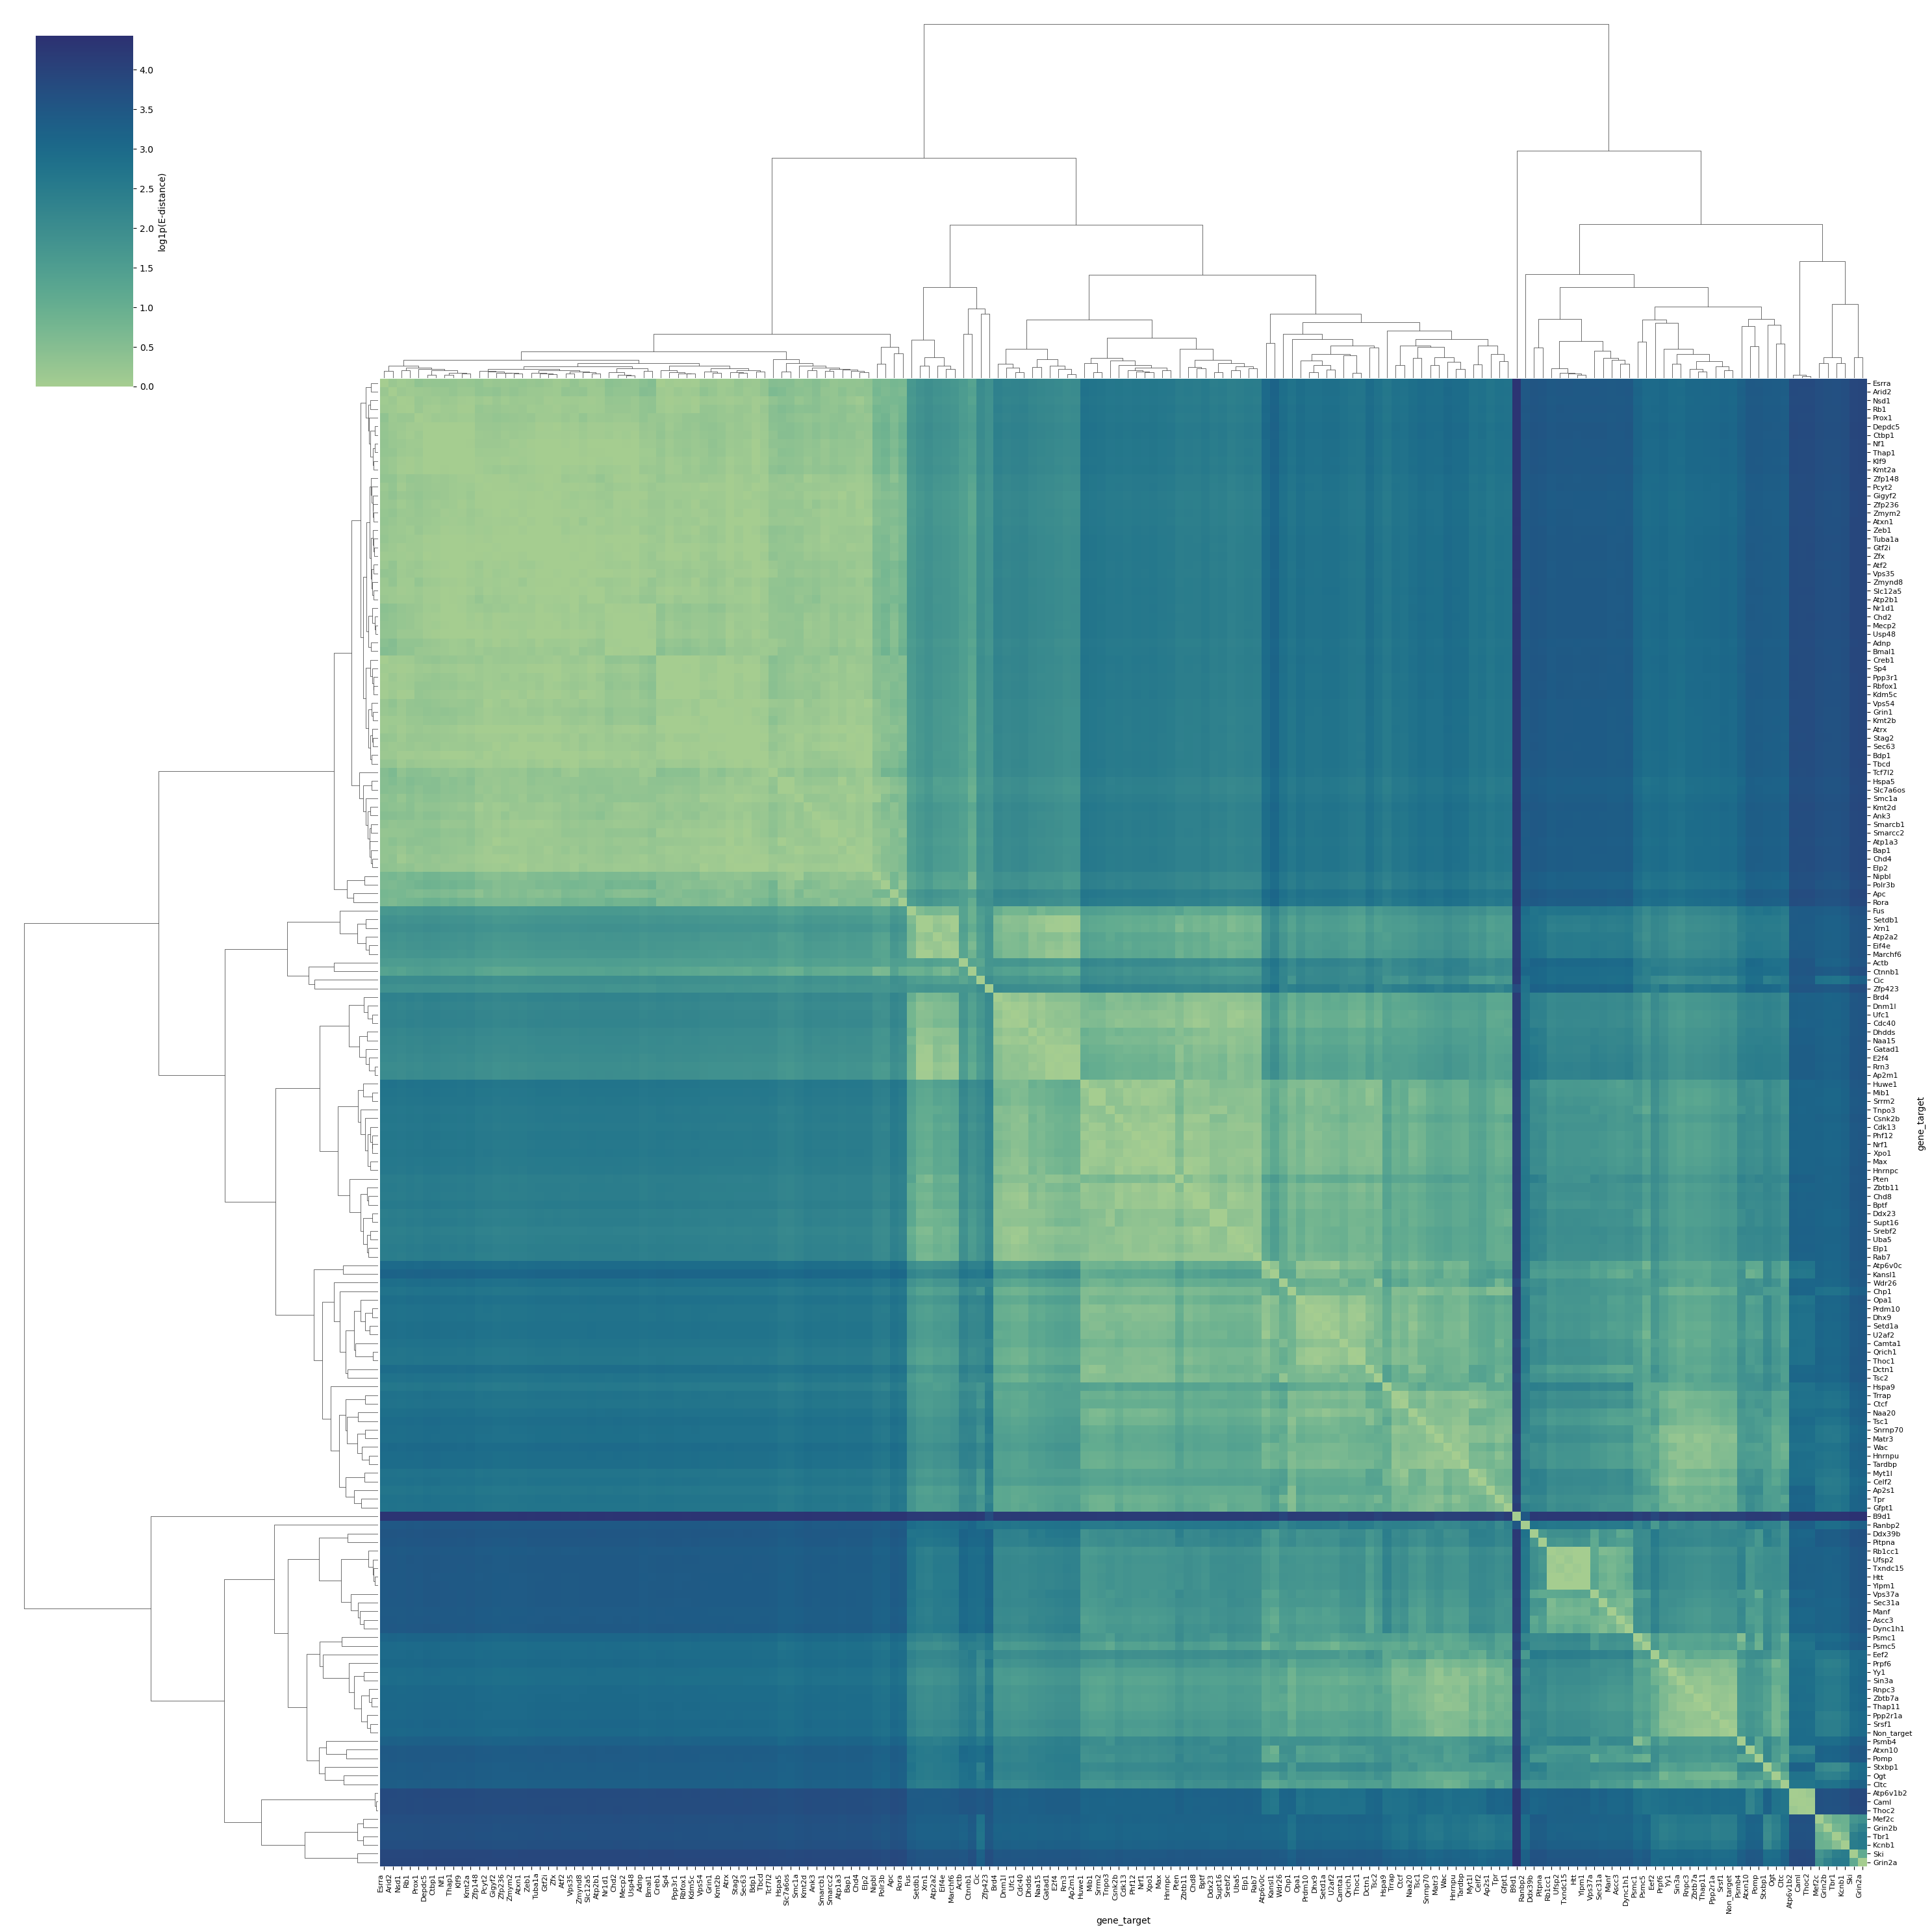

In [ ]:
%matplotlib inline
plot_and_save_clustermaps(results_dict, out_dir=cell_type_col, save=False)

Clustermap: MB-HB-Glut-Sero-Dopa


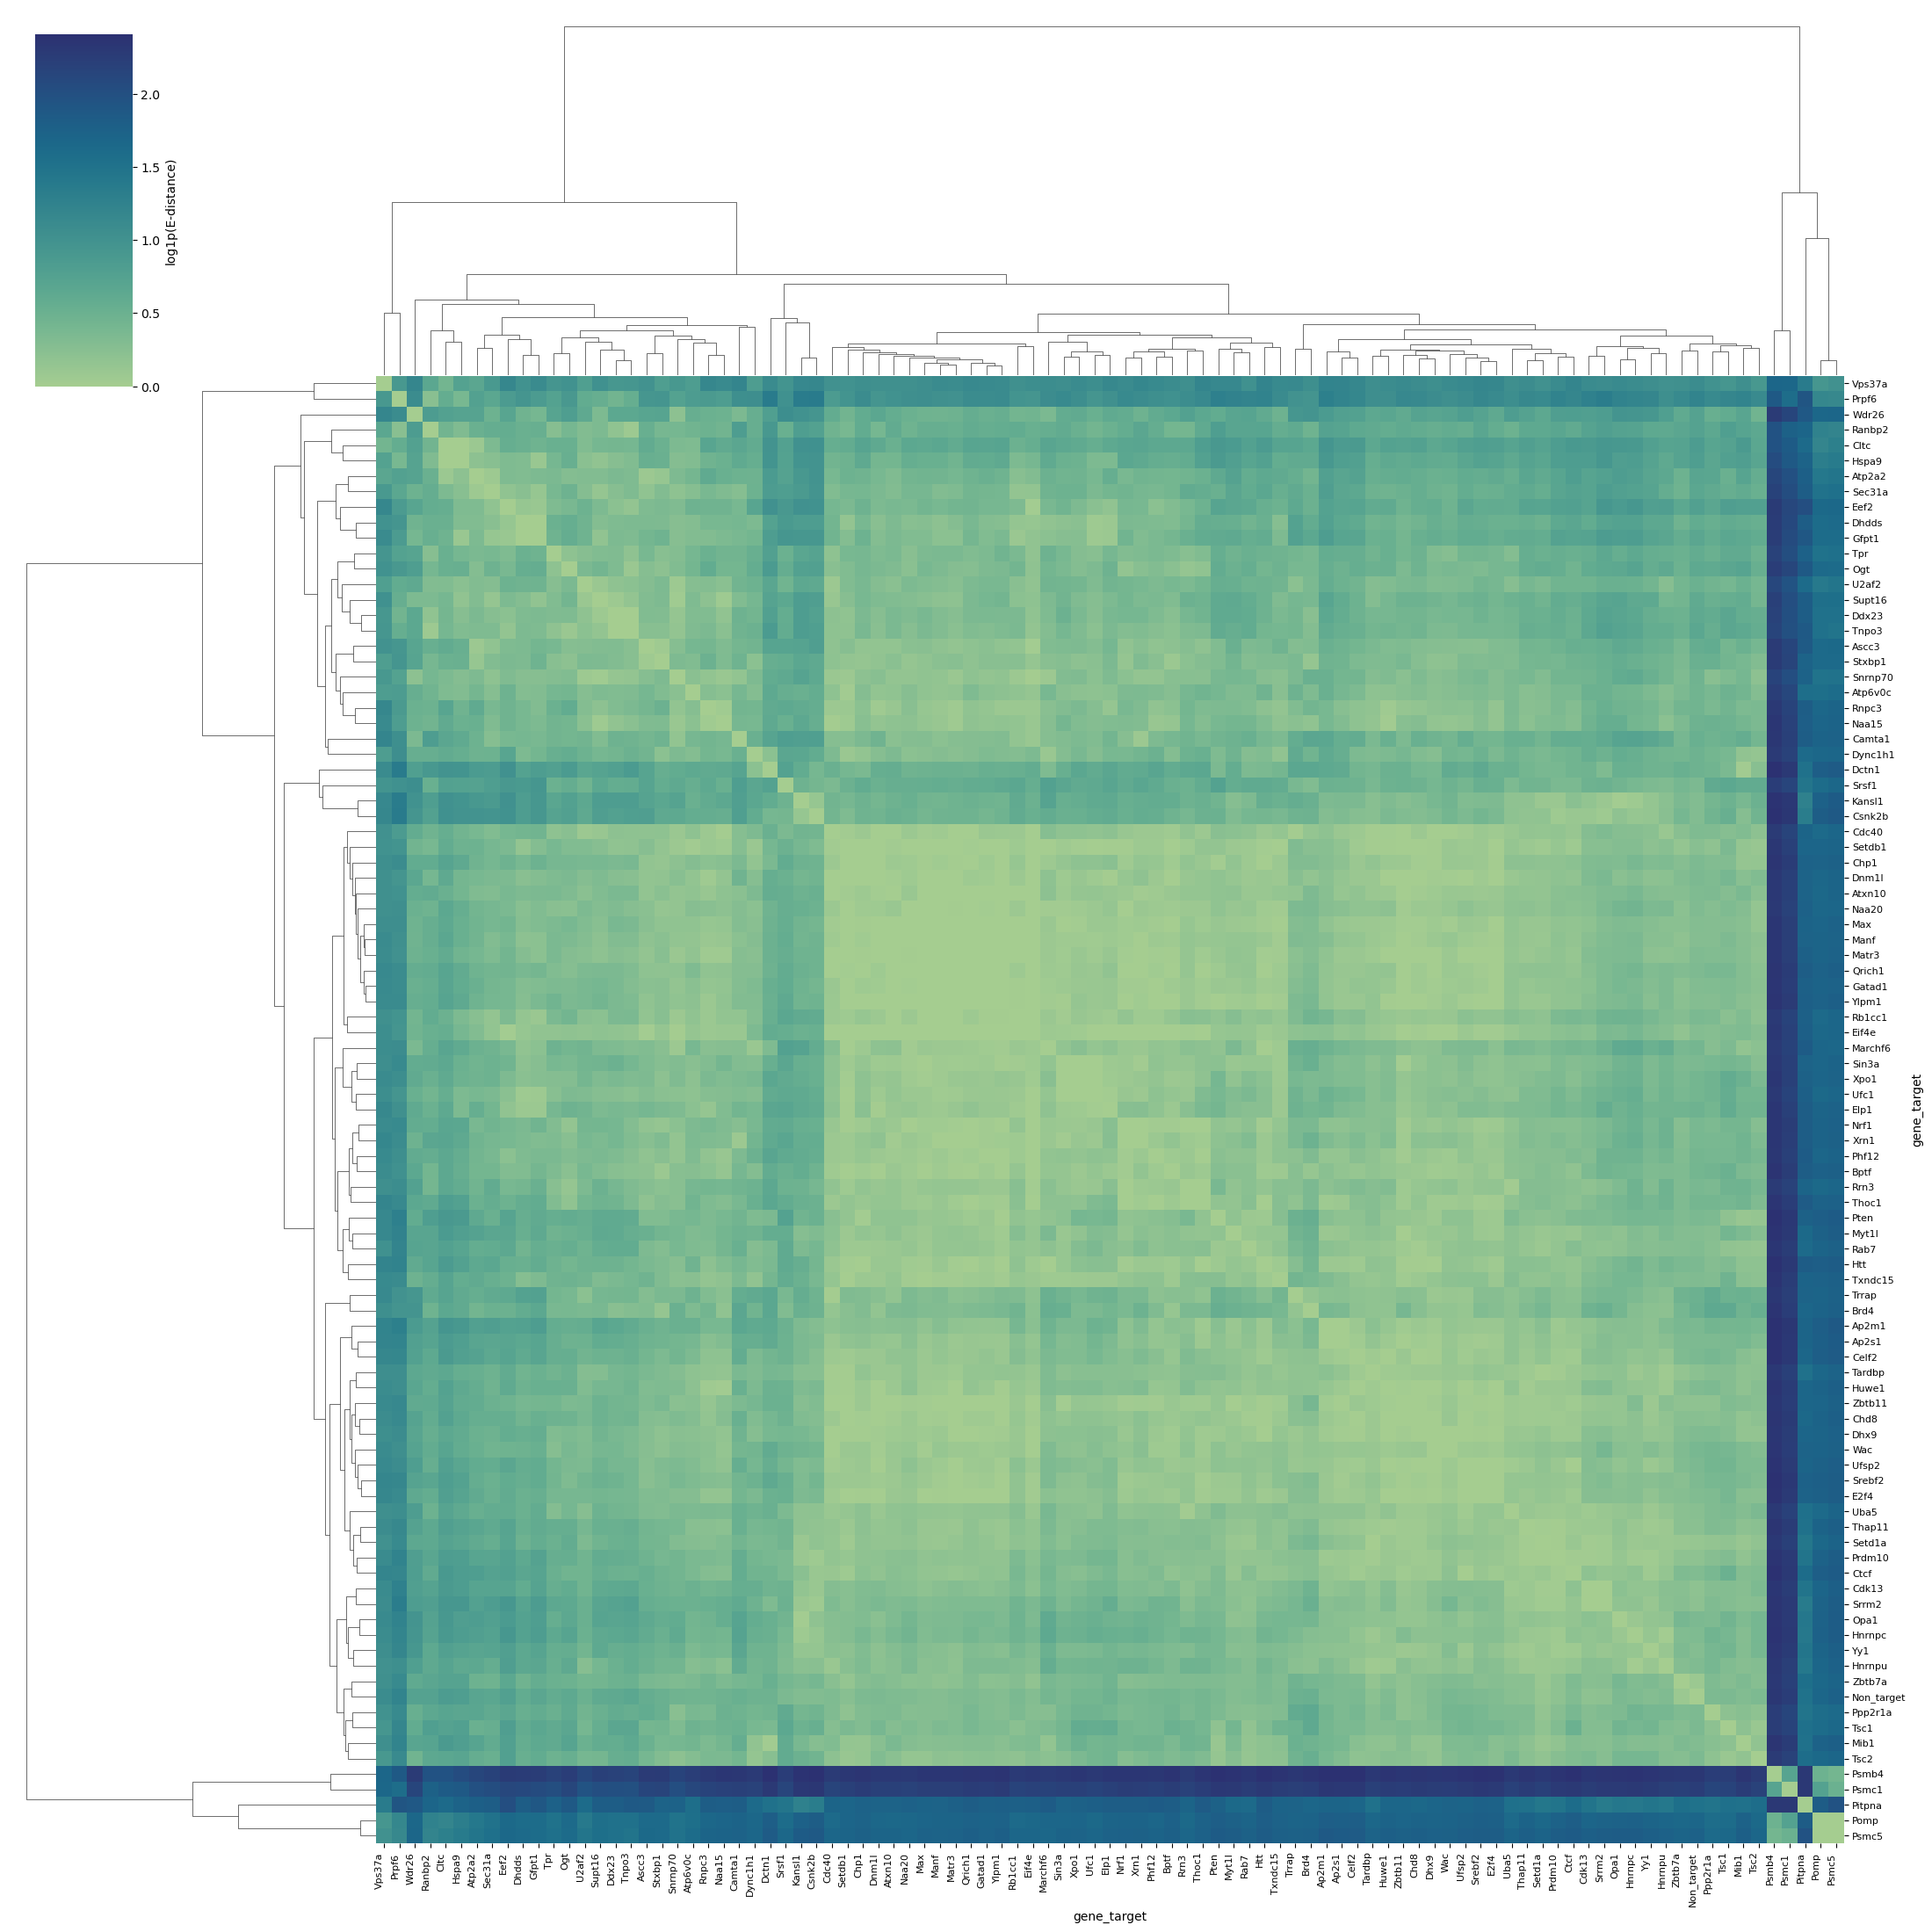

Clustermap: TH-EPI-Glut


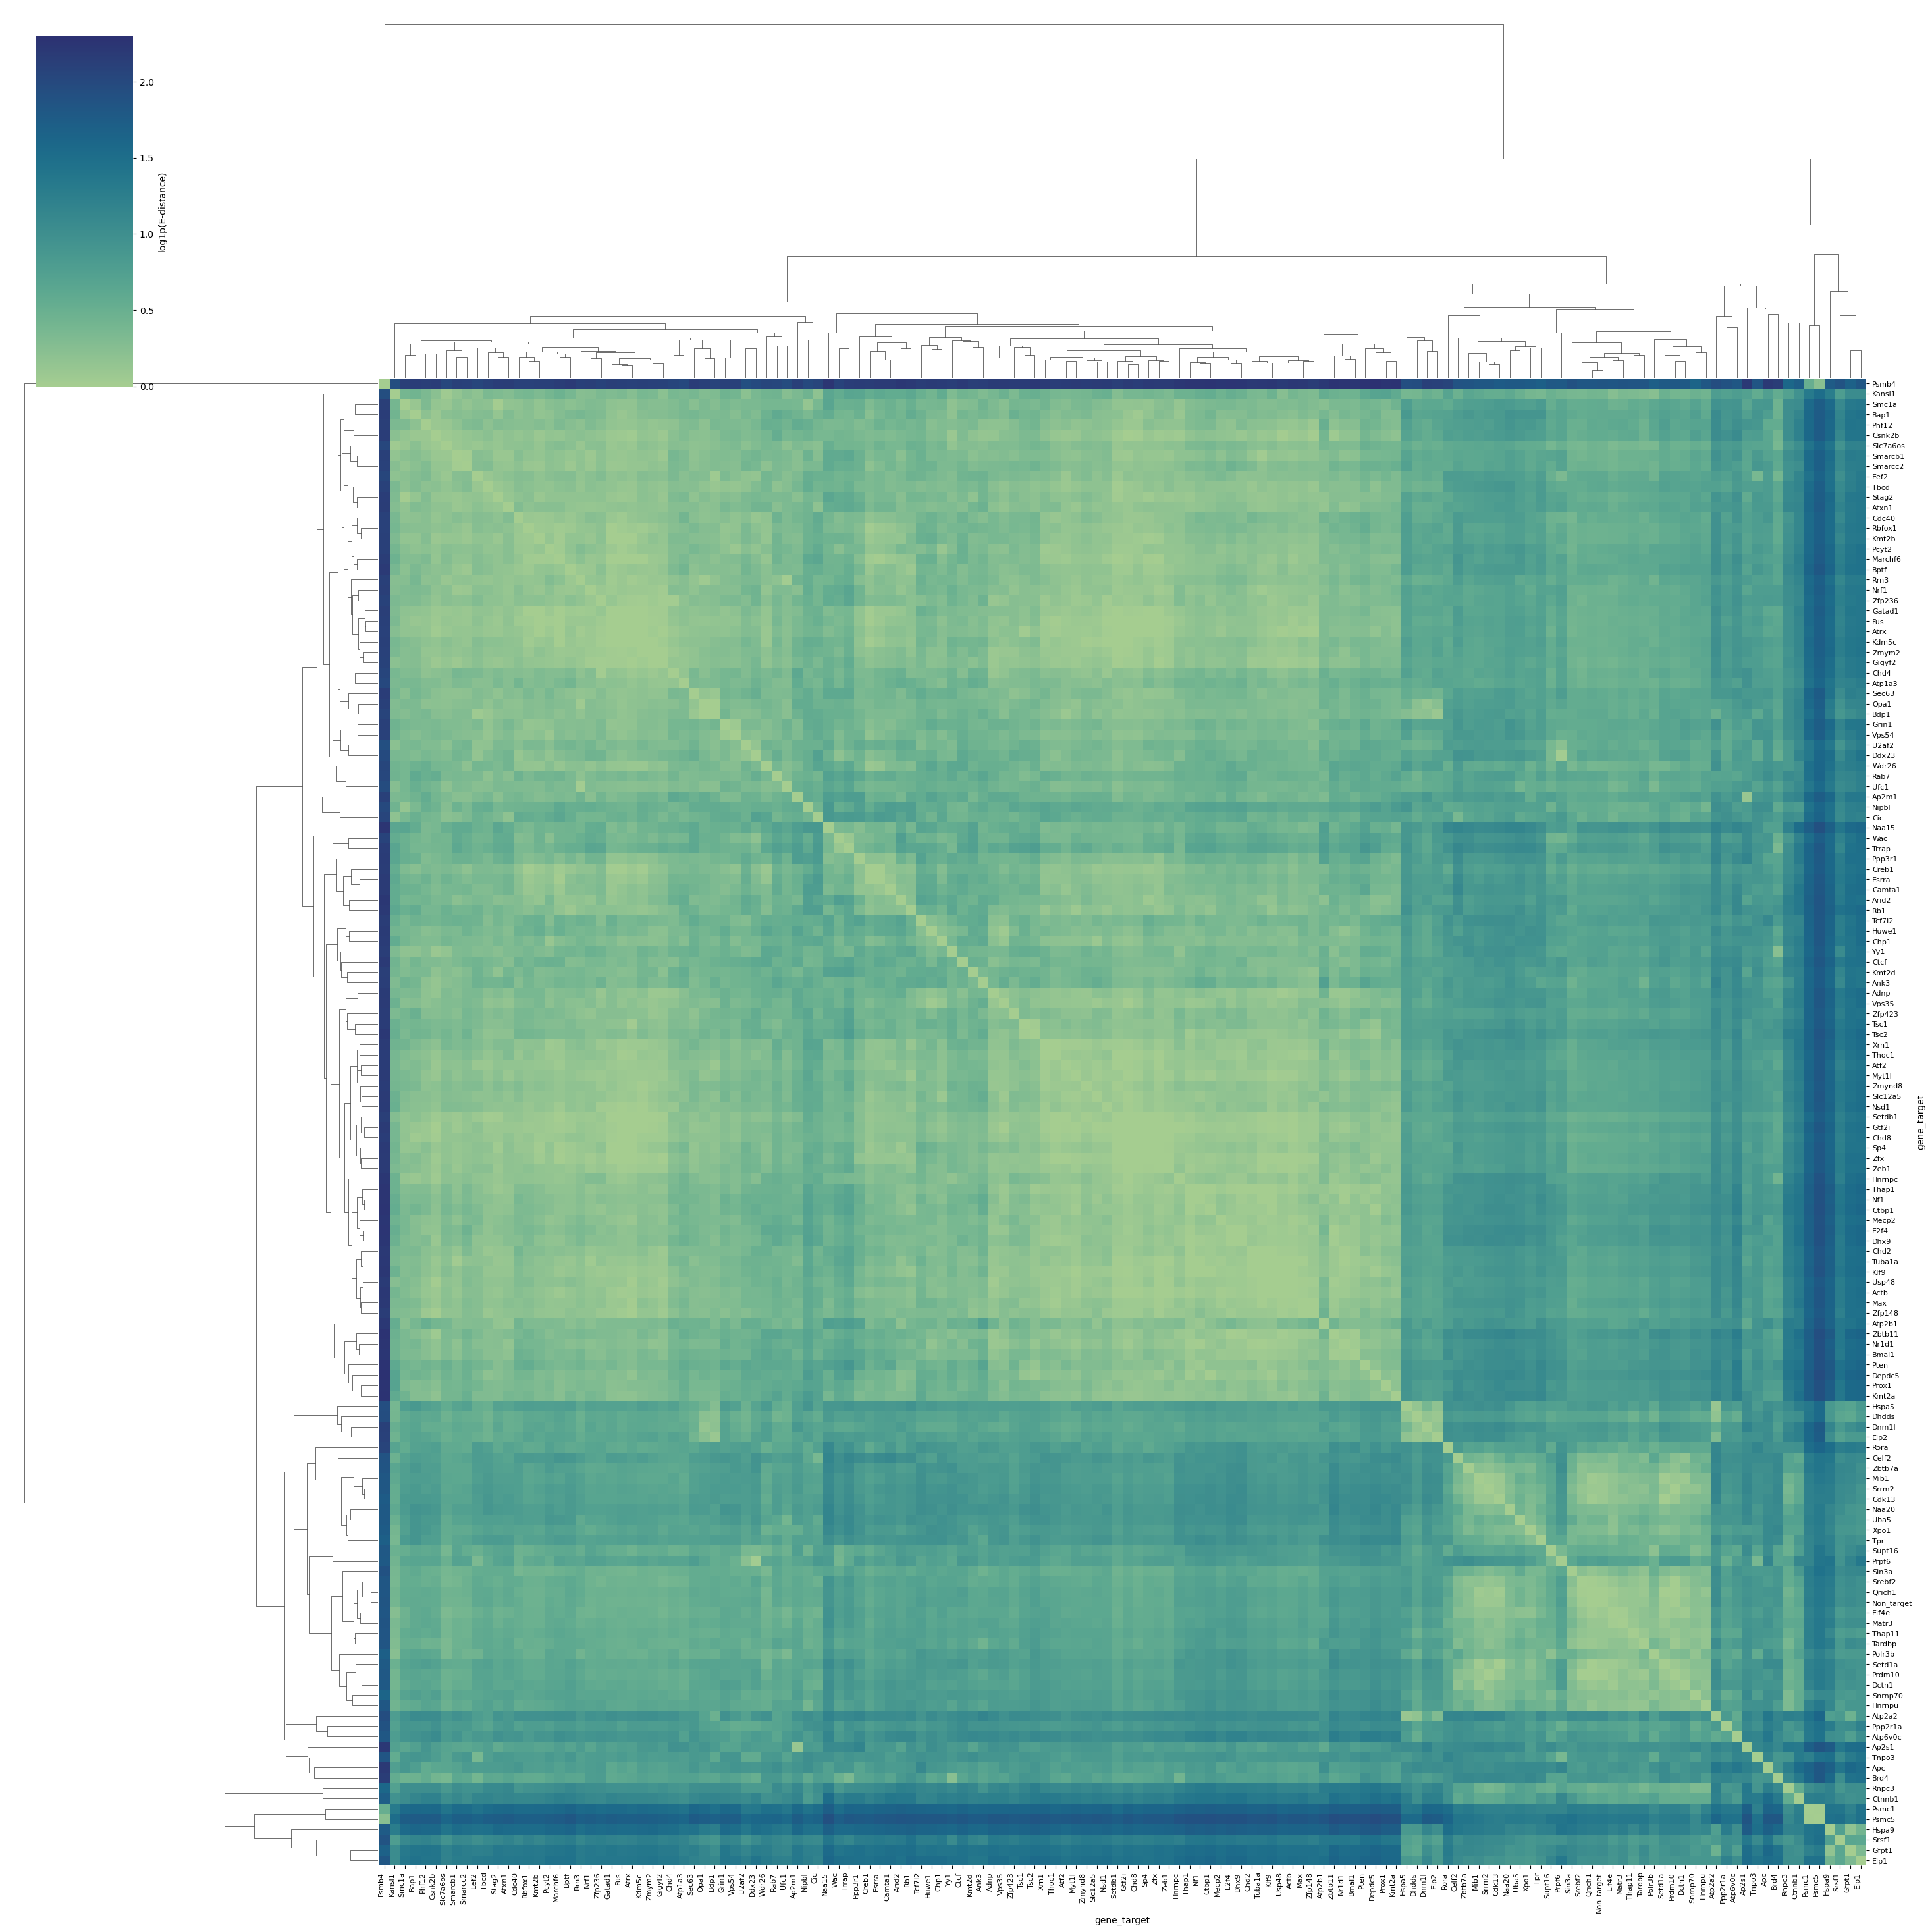

Clustermap: Pallium-Glut


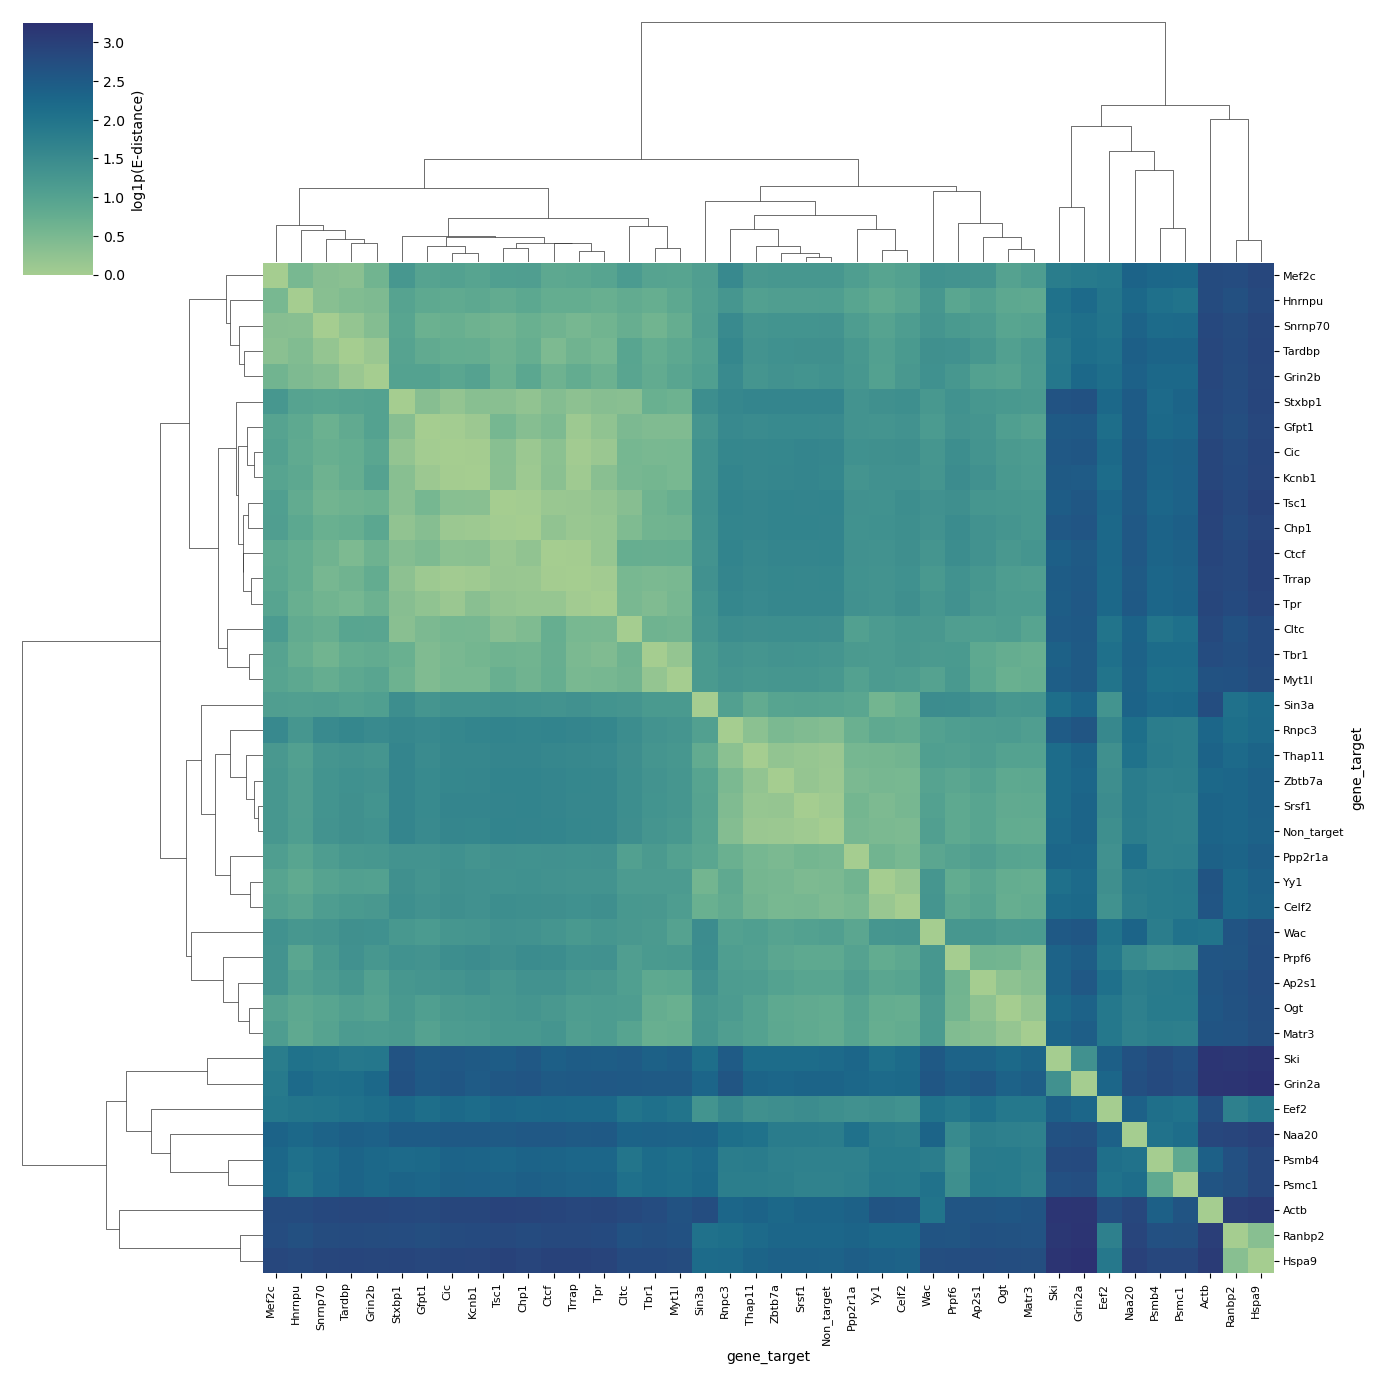

Clustermap: MB-HB-CB-GABA


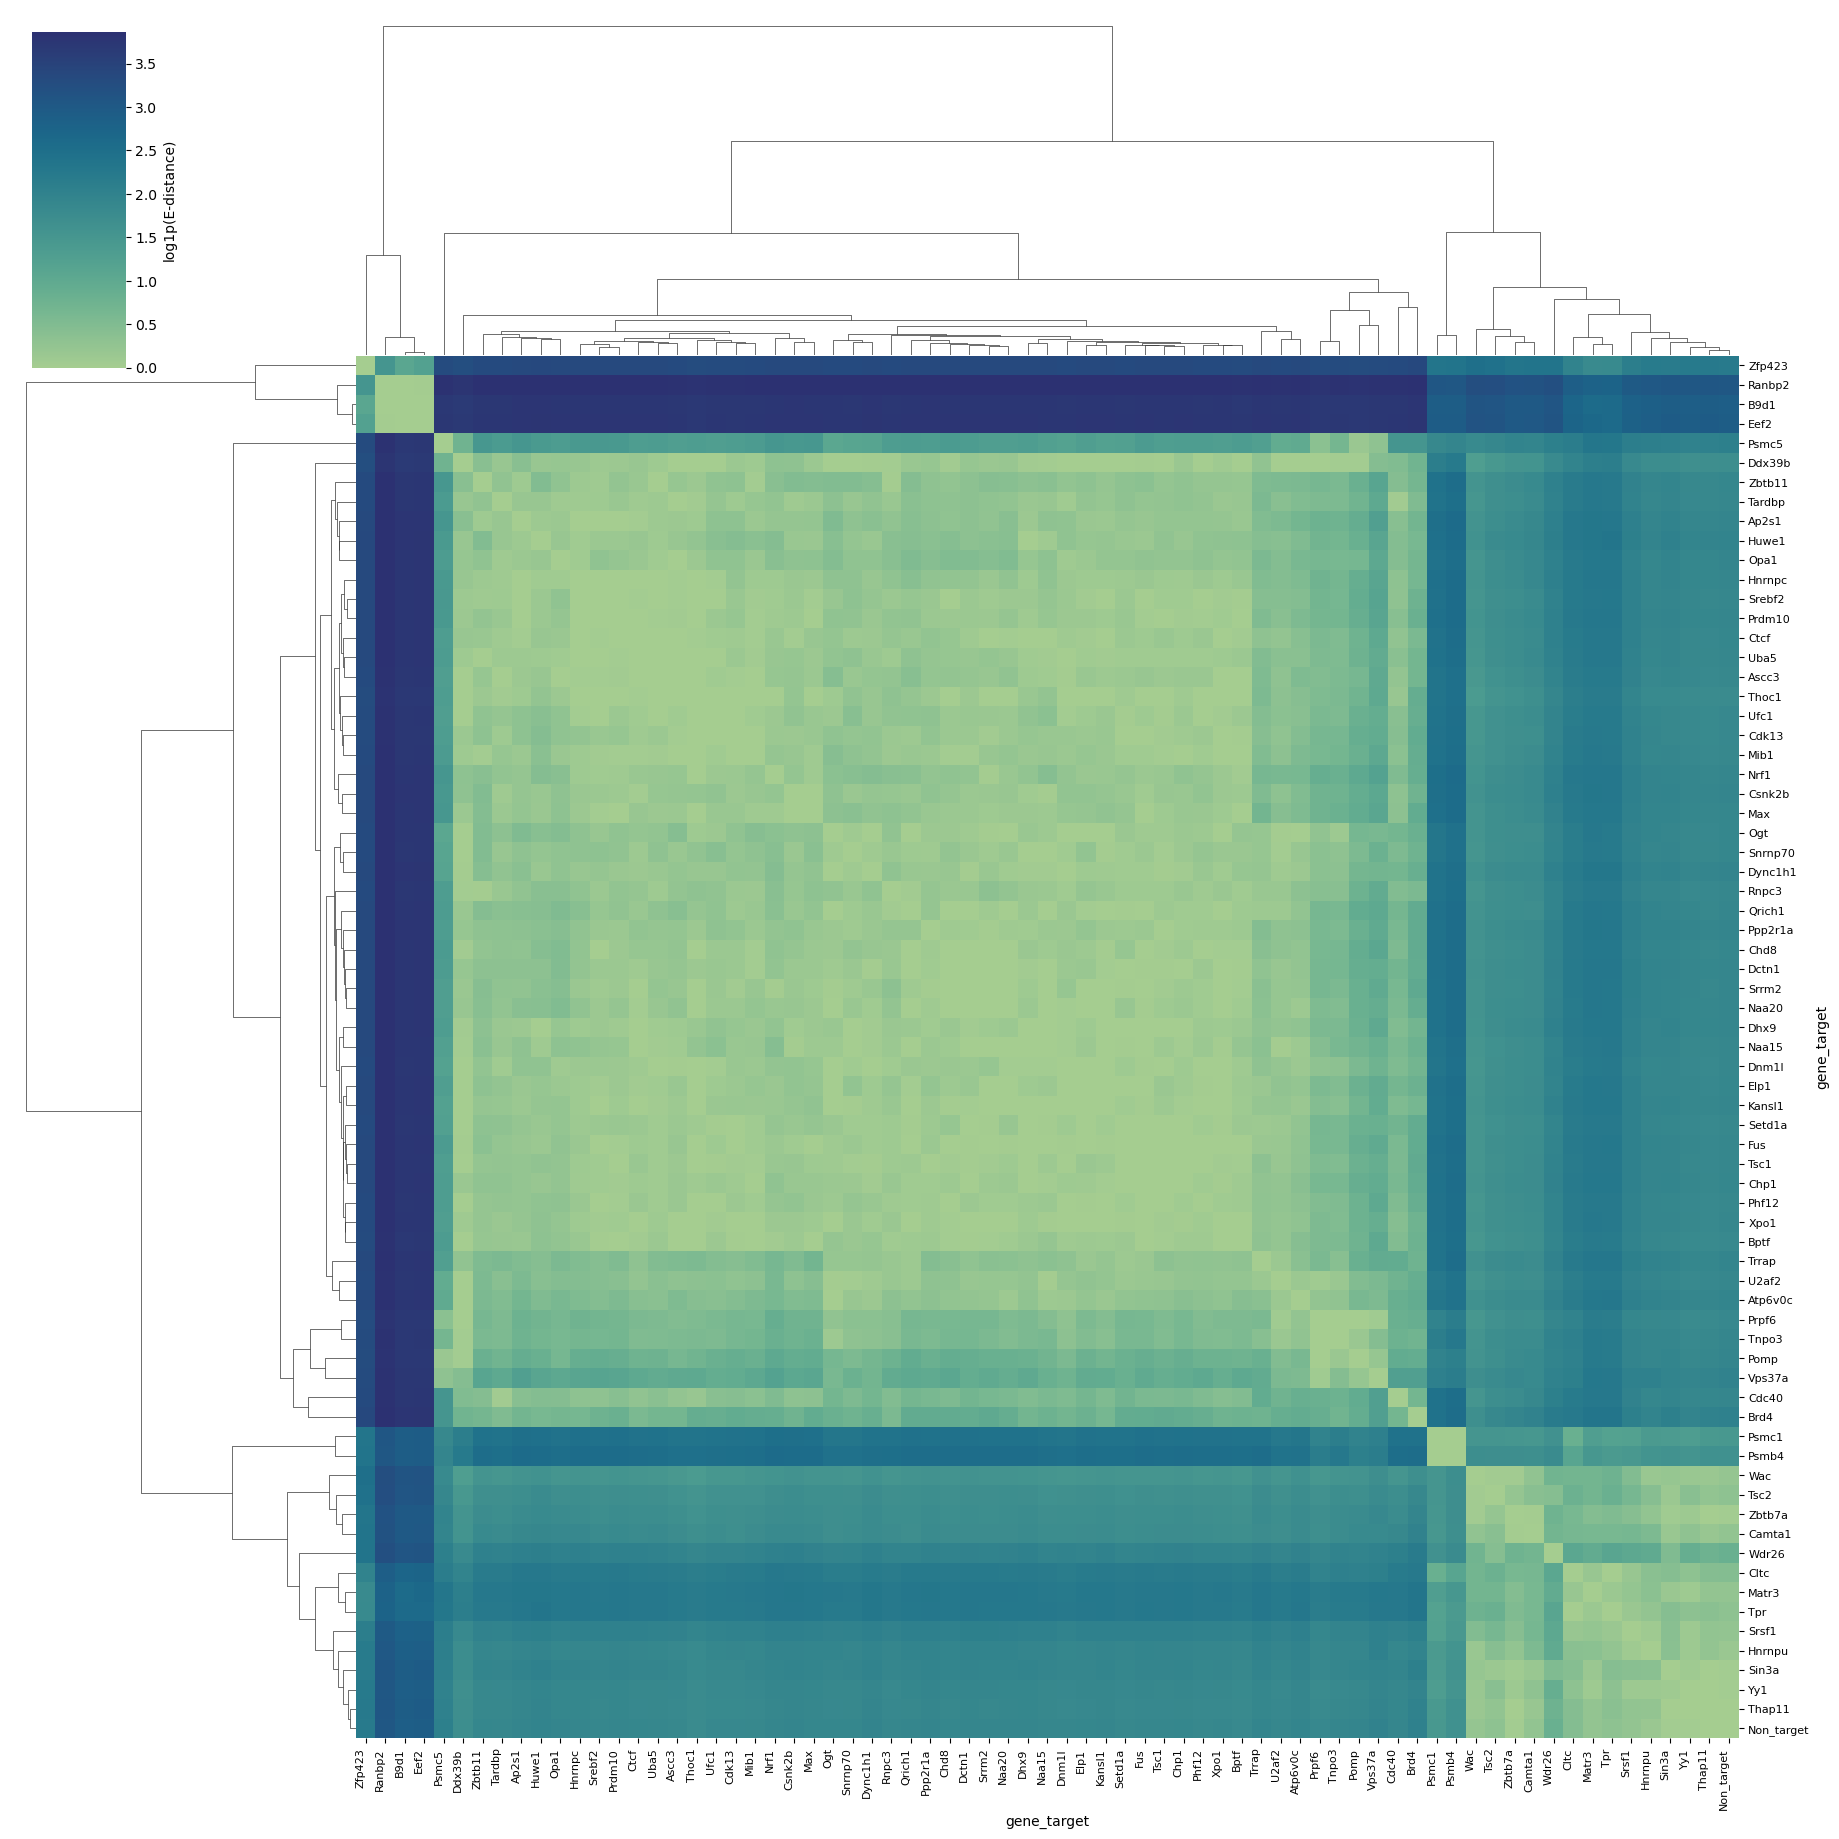

Clustermap: Subpallium-GABA; HY-EA-Glut-GABA


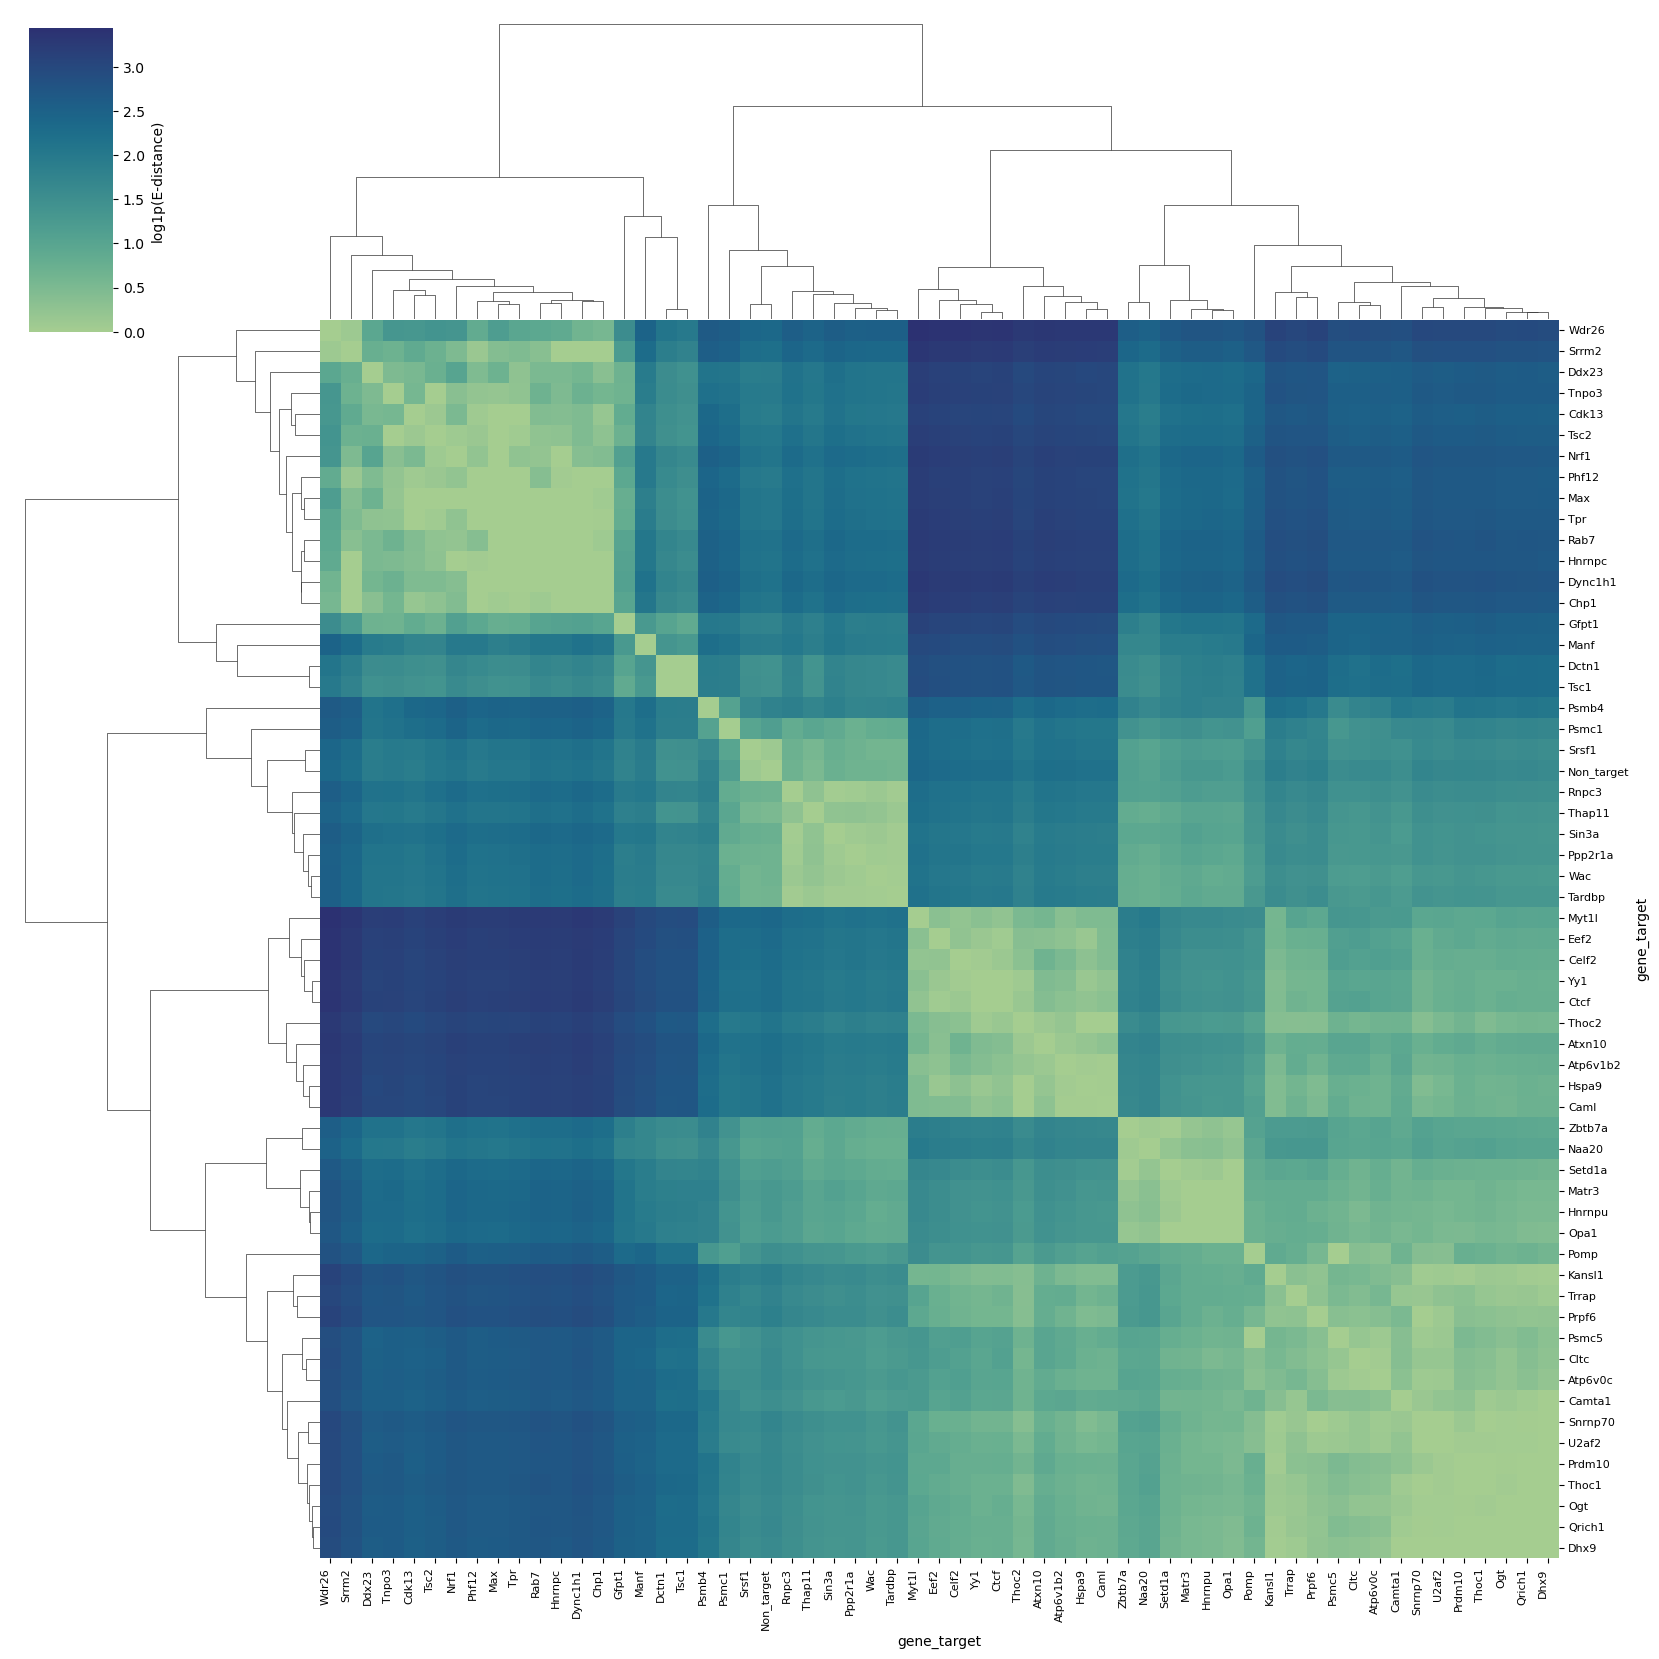

Clustermap: HY-EA-Glut-GABA


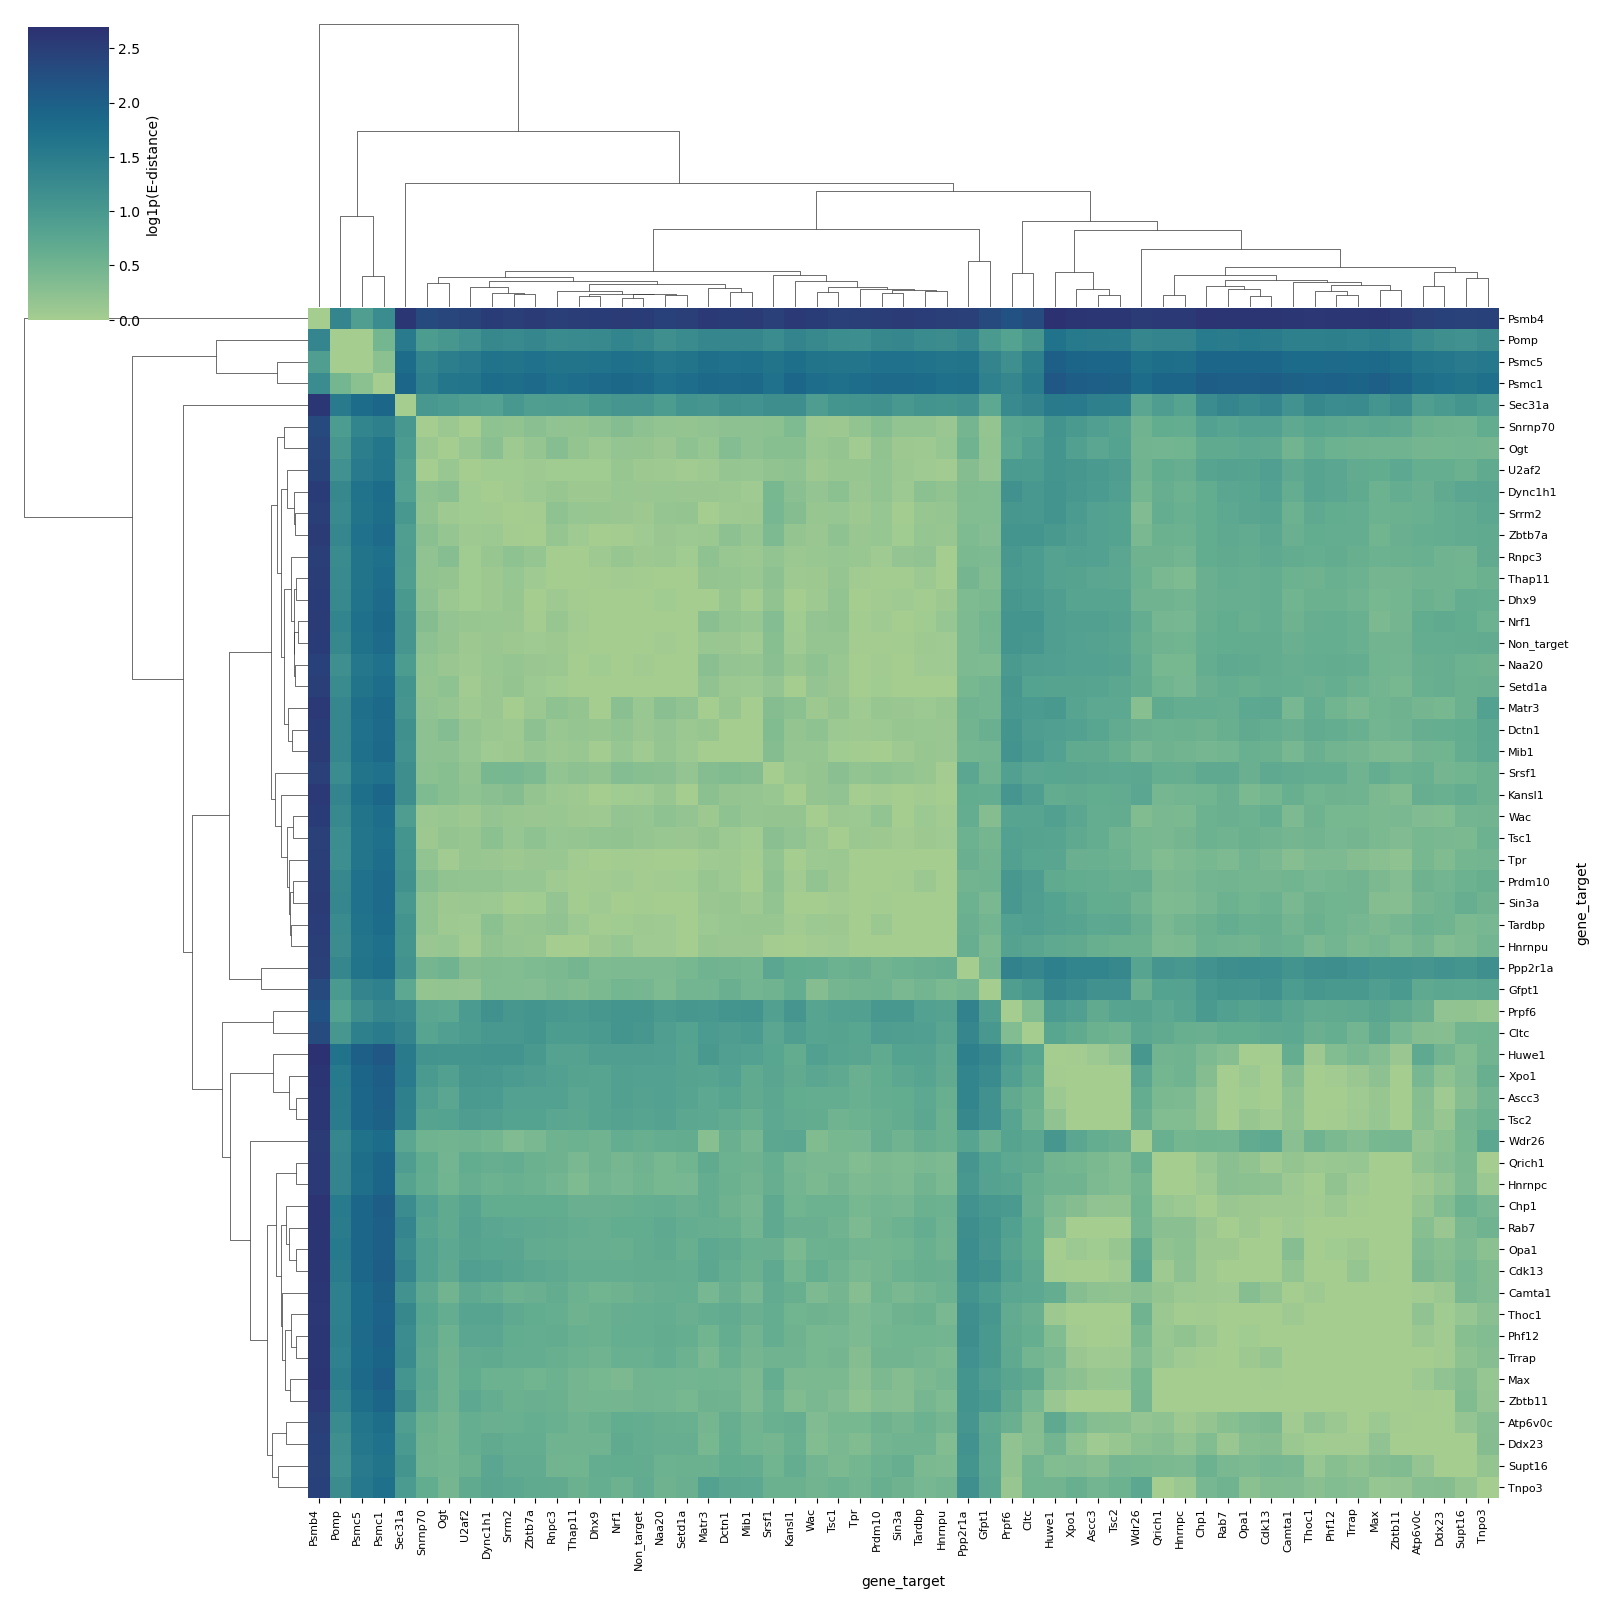

Clustermap: Subpallium-GABA


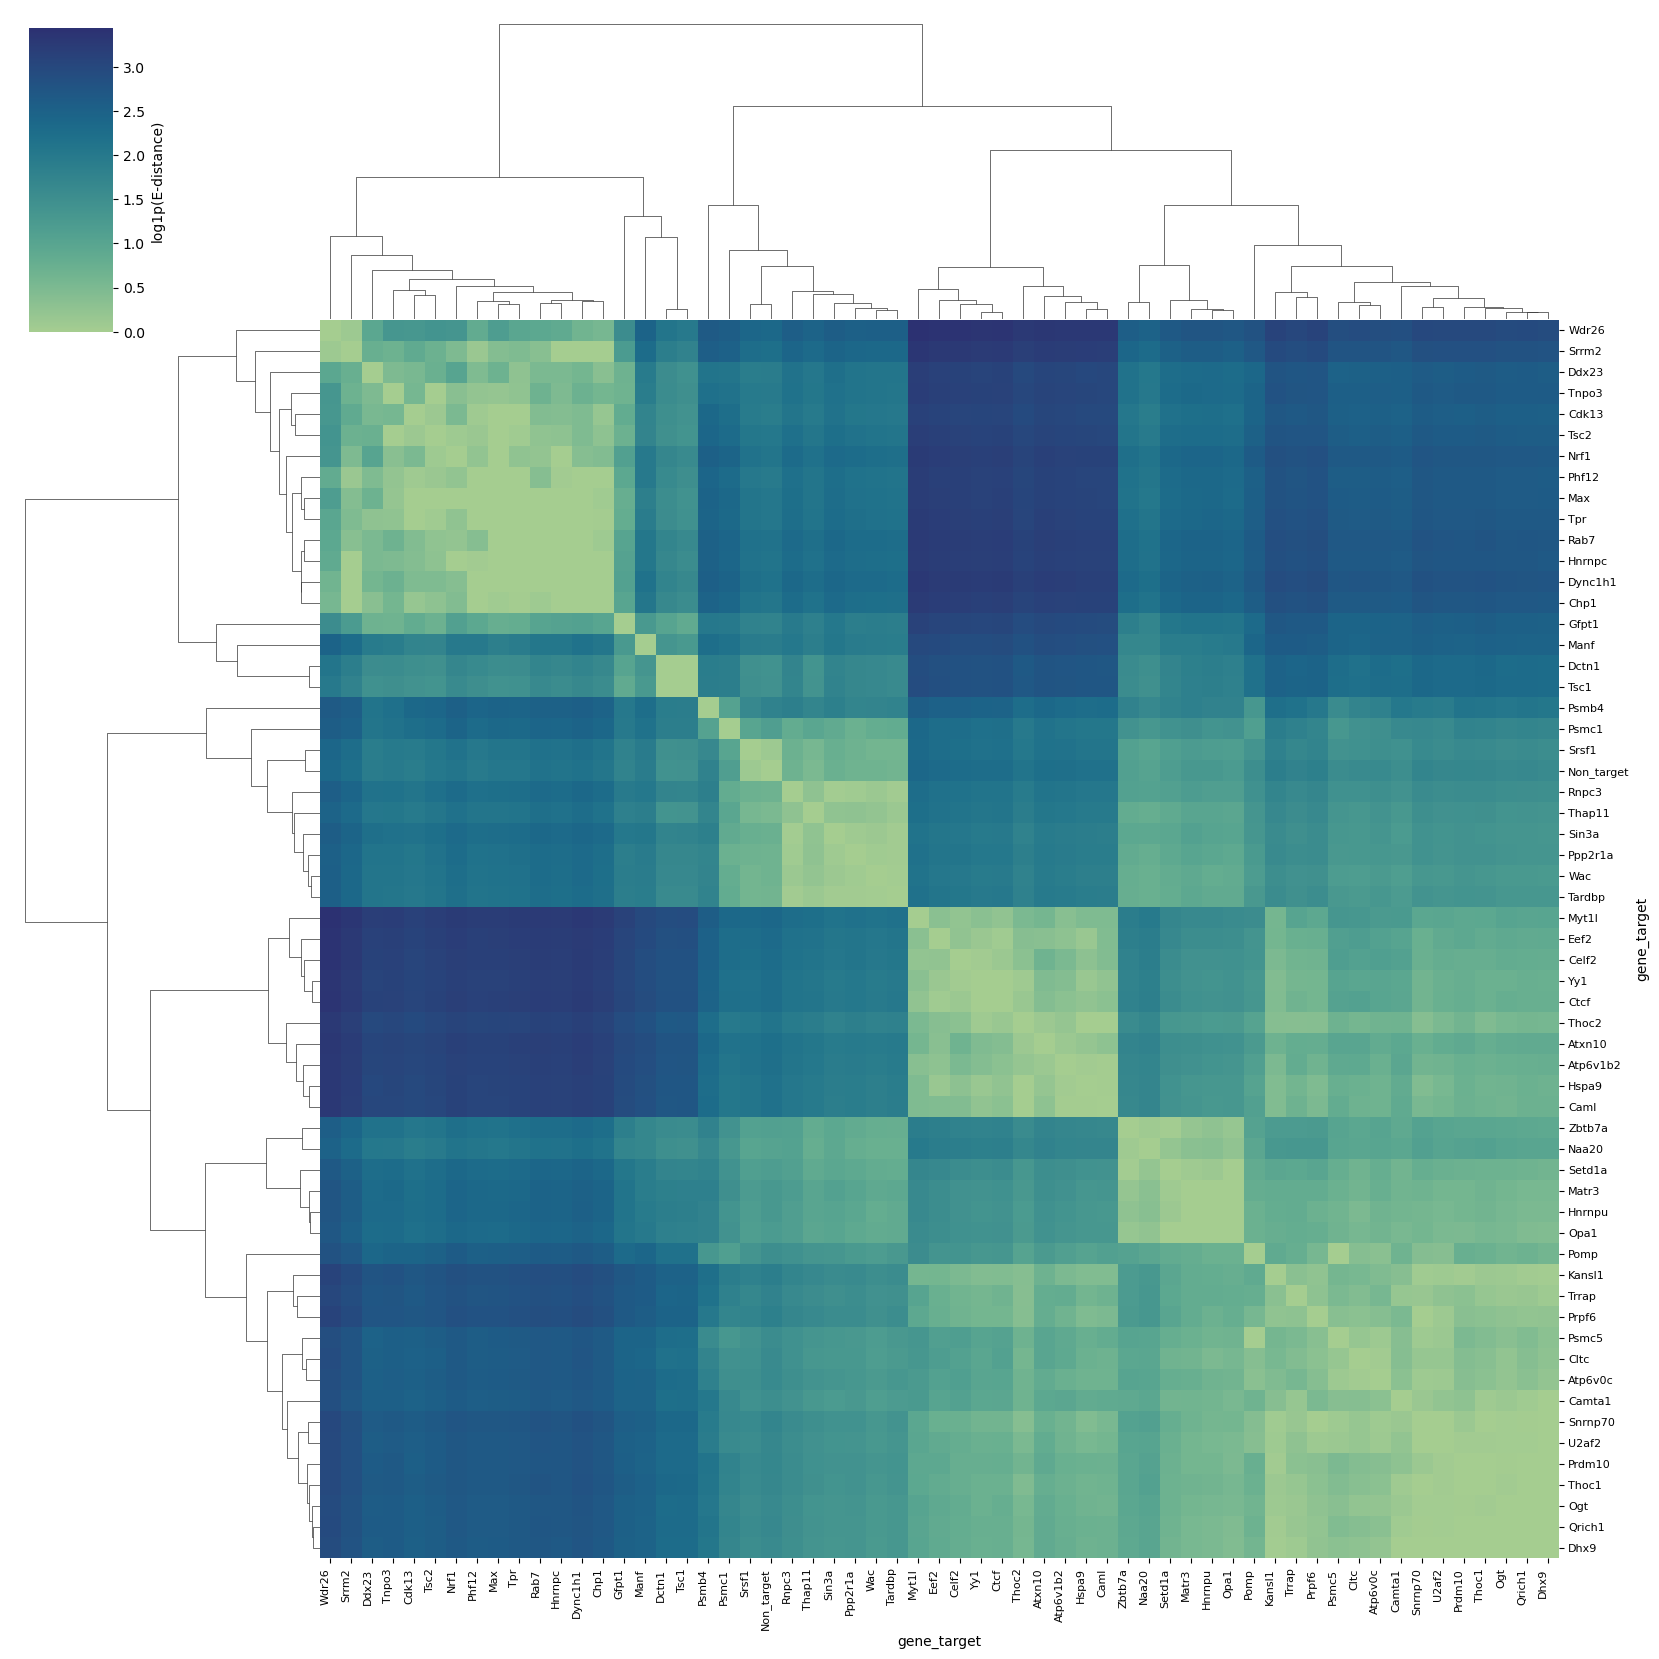

In [ ]:
%matplotlib inline
plot_and_save_clustermaps(all_cell_type_results["neighborhood"], out_dir="neighborhood", save=False)